# CPE393 — Final Project: Predicting Airbnb Listing Prices**Group 15 K/B — Mathieu, Serghei, Samy****Course:** CPE393 - Introduction to Data Science with Python | Summer 2026 | KMUTT**Dataset:** AirBnB Listings in Major US Cities (Deloitte ML Competition) — [Kaggle link](https://www.kaggle.com/datasets/rudymizrahi/airbnb-listings-in-major-us-cities-deloitte-ml)**Goal:** Build regression models that predict the price of an Airbnb listing (`log_price`) from property and location features. This is a **regression** problem.

## 0. ImportsWe import all the libraries we will use throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42  # fixed seed so results are reproducible

## 1. Load the original dataset and split it into train / test (80% / 20%)The Kaggle dataset comes as a single file `train.csv` with **74,111 listings** and **29 columns**. As required, we split it ourselves into two parts:- `airbnb_train.csv` &rarr; **80%** of the rows, used to train the models- `airbnb_test.csv` &rarr; **20%** of the rows, kept aside to test the modelsWe use a fixed `random_state` so the split is always the same (reproducible).

In [2]:
# Load the full dataset downloaded from Kaggle.
# Put 'train.csv' next to this notebook. We try a few common paths so the
# notebook runs the same on Colab, Jupyter or a local machine.
import os
for _path in ['train.csv', 'data/train.csv', '/content/train.csv']:
    if os.path.exists(_path):
        DATA_PATH = _path
        break
else:
    raise FileNotFoundError(
        "train.csv not found. Download it from the Kaggle link at the top "
        "and place it next to this notebook."
    )

full_data = pd.read_csv(DATA_PATH)
print('Loaded from:', DATA_PATH)
print('Full dataset shape:', full_data.shape)

# Split 80% train / 20% test
airbnb_train, airbnb_test = train_test_split(
    full_data, test_size=0.2, random_state=RANDOM_STATE
)

# Save the two files
airbnb_train.to_csv('airbnb_train.csv', index=False)
airbnb_test.to_csv('airbnb_test.csv', index=False)

print('Training set:', airbnb_train.shape, '-> saved as airbnb_train.csv')
print('Test set:    ', airbnb_test.shape, '-> saved as airbnb_test.csv')

Loaded from: train.csv
Full dataset shape: (74111, 29)
Training set: (59288, 29) -> saved as airbnb_train.csv
Test set:     (14823, 29) -> saved as airbnb_test.csv


## 2. Data explorationWe first look at the training data to understand its structure, the column types, and possible issues.

In [3]:
data = pd.read_csv('airbnb_train.csv')

print(data.head())
print()
data.info()
print()
print('Columns:', list(data.columns))

         id  log_price property_type        room_type  \
0    760827   4.499810         House  Entire home/apt   
1   3257345   3.806662     Apartment  Entire home/apt   
2  13355012   5.075174     Apartment  Entire home/apt   
3   4565981   4.442651     Apartment     Private room   
4   6940108   4.744932     Apartment  Entire home/apt   

                                           amenities  accommodates  bathrooms  \
0  {TV,"Cable TV",Internet,"Wireless Internet","A...             4        1.5   
1  {TV,"Wireless Internet",Kitchen,"Free parking ...             2        1.0   
2  {TV,"Air conditioning",Kitchen,Heating,"Smoke ...             4        1.0   
3                                                 {}             2        1.0   
4  {Internet,"Wireless Internet","Air conditionin...             3        1.0   

   bed_type cancellation_policy  cleaning_fee  ...   latitude   longitude  \
0  Real Bed            flexible         False  ...  34.109039 -118.273390   
1  Real Bed     

Let's look at some descriptive statistics and plot a few graphs to understand the data more clearly.

                 id     log_price  accommodates     bathrooms      latitude  \
count  5.928800e+04  59288.000000  59288.000000  59128.000000  59288.000000   
mean   1.126102e+07      4.780538      3.152054      1.236183     38.450807   
std    6.087273e+06      0.717547      2.153512      0.582392      3.080455   
min    9.410000e+02      0.000000      1.000000      0.000000     33.338905   
25%    6.245493e+06      4.304065      2.000000      1.000000     34.128782   
50%    1.224695e+07      4.700480      2.000000      1.000000     40.663197   
75%    1.640730e+07      5.220356      4.000000      1.000000     40.746167   
max    2.123090e+07      7.600402     16.000000      8.000000     42.390437   

          longitude  number_of_reviews  review_scores_rating      bedrooms  \
count  59288.000000       59288.000000          45893.000000  59210.000000   
mean     -92.349408          20.935805             94.076526      1.265817   
std       21.688276          37.950408              7.

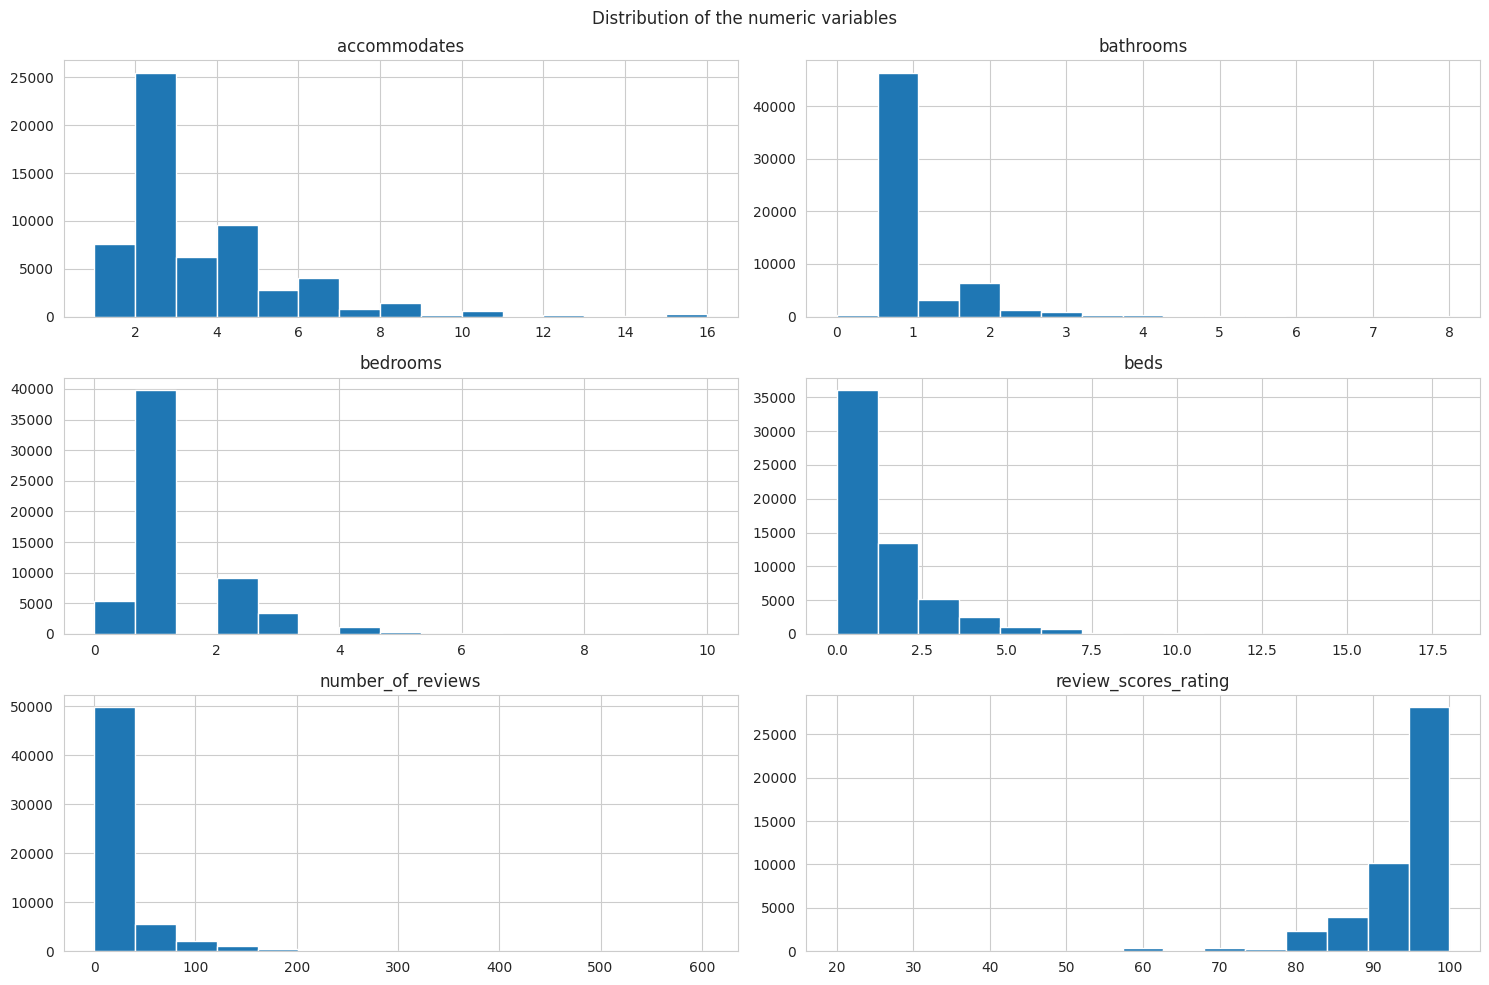

In [4]:
# Descriptive statistics of the numeric columns
print(data.describe())

# Distributions of the main numeric variables
numeric_columns = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
                   'number_of_reviews', 'review_scores_rating']
data[numeric_columns].hist(bins=15, figsize=(15, 10))
plt.suptitle('Distribution of the numeric variables')
plt.tight_layout()
plt.show()

**Interpretation.** `accommodates`, `bedrooms`, `beds` and `bathrooms` are right-skewed: most listings are small (1-2 bedrooms, capacity 2-4). `number_of_reviews` has a very long tail (a few listings with hundreds of reviews), and `review_scores_rating` is strongly concentrated near 90-100, so it will carry little discriminating power on its own.

We plot the distribution of the categorical variables to see the most common categories.

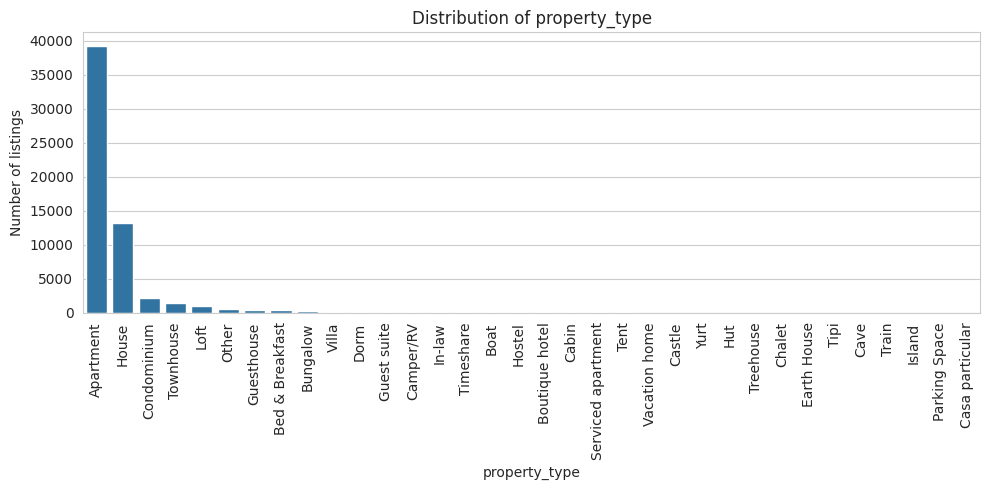

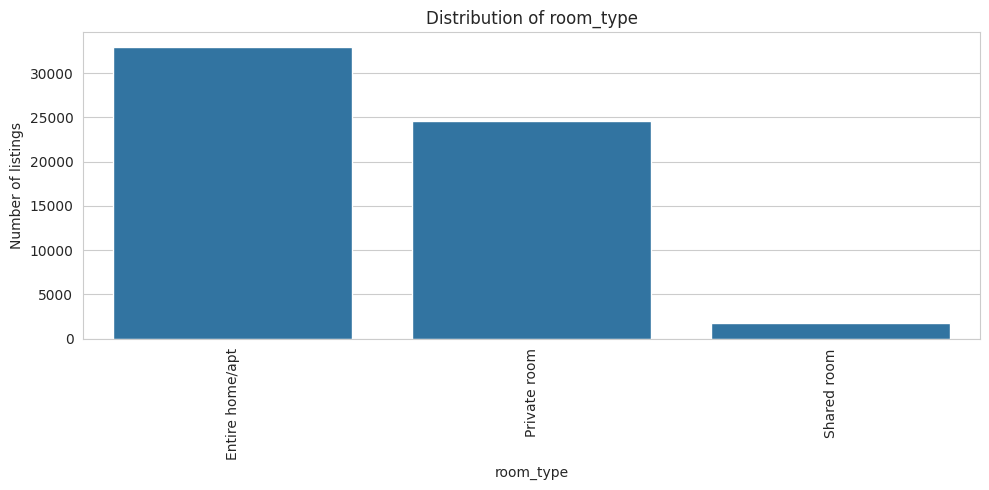

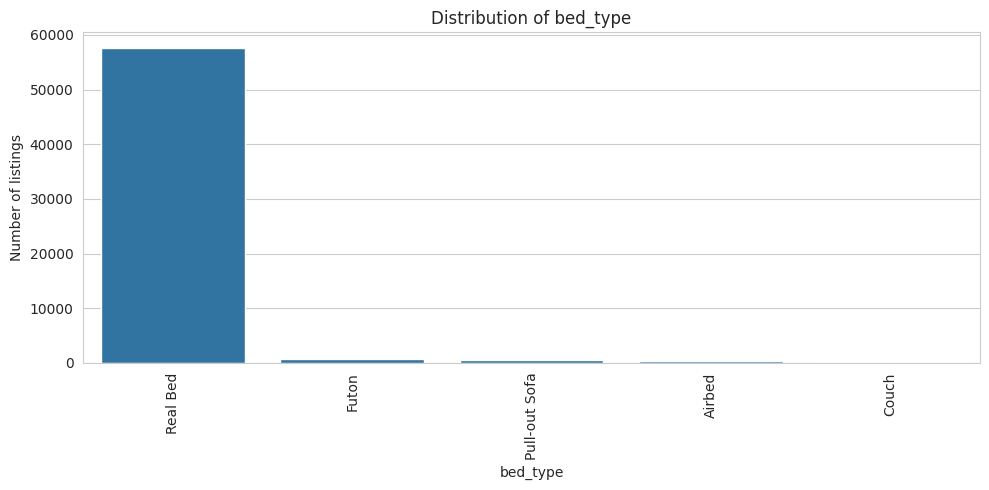

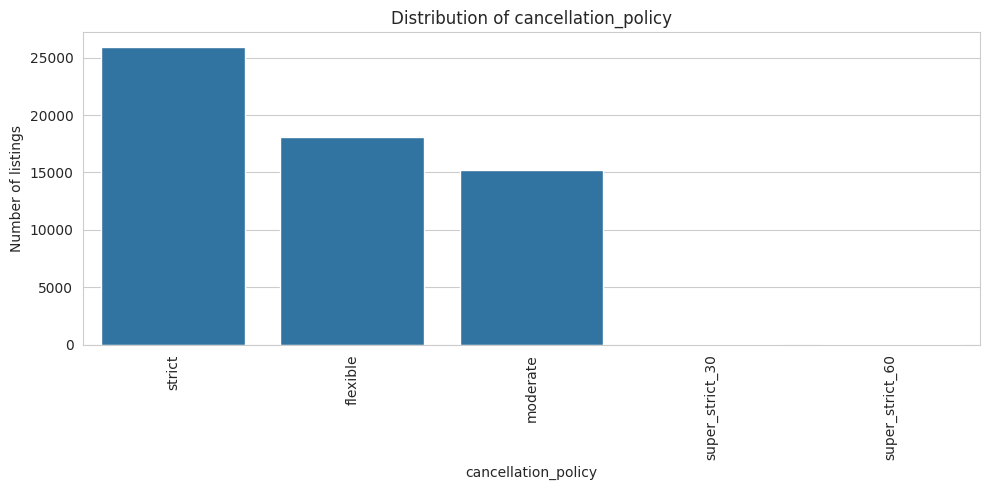

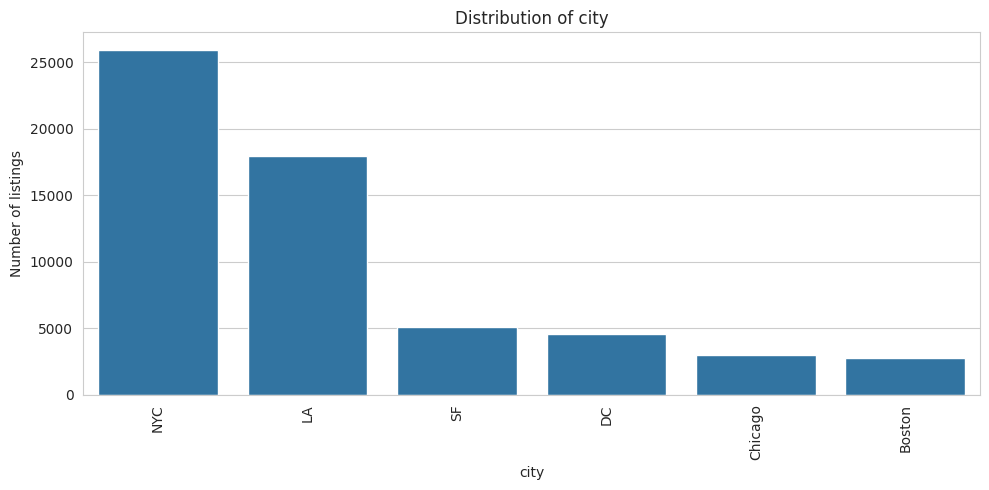

In [5]:
# Distributions of the categorical variables
categorical_columns = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city']

for column in categorical_columns:
    plt.figure(figsize=(10, 5))
    order = data[column].value_counts().index
    sns.countplot(data=data, x=column, order=order)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Number of listings')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

**Interpretation.** The dataset is dominated by **Apartments**, **Entire home/apt** listings and **Real Bed** / **strict** policies. **NYC (~26k)** and **LA (~18k)** make up most of the rows, while Boston and Chicago are under-represented (~3k each). This class imbalance across cities is worth keeping in mind when we interpret city-level effects.

### Target variable: `log_price``log_price` is the natural logarithm of the nightly price. The raw price is heavily right-skewed, so taking the log makes the distribution closer to normal, which helps the regression models.

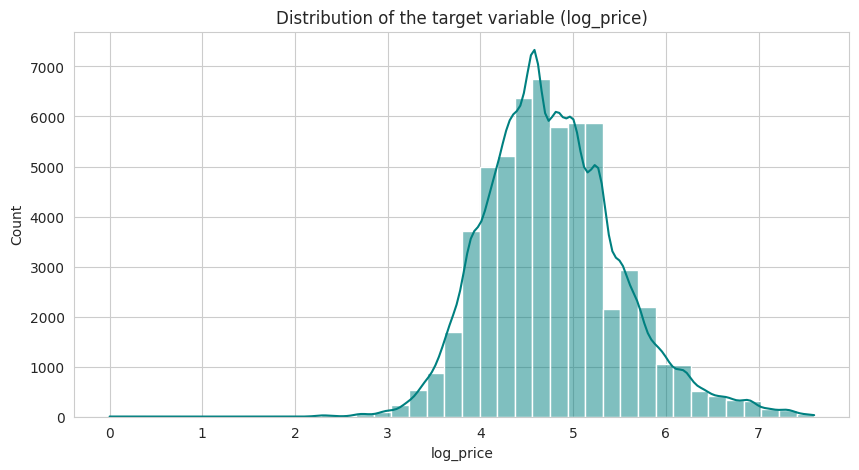

Price (log) statistics:
count    59288.000000
mean         4.780538
std          0.717547
min          0.000000
25%          4.304065
50%          4.700480
75%          5.220356
max          7.600402
Name: log_price, dtype: float64


In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(data['log_price'], kde=True, bins=40, color='teal')
plt.title('Distribution of the target variable (log_price)')
plt.xlabel('log_price')
plt.ylabel('Count')
plt.show()

print('Price (log) statistics:')
print(data['log_price'].describe())

### Price by city and room typeThese two plots show how the price changes depending on the city and the type of room. They give a first idea of which features matter for predicting the price.

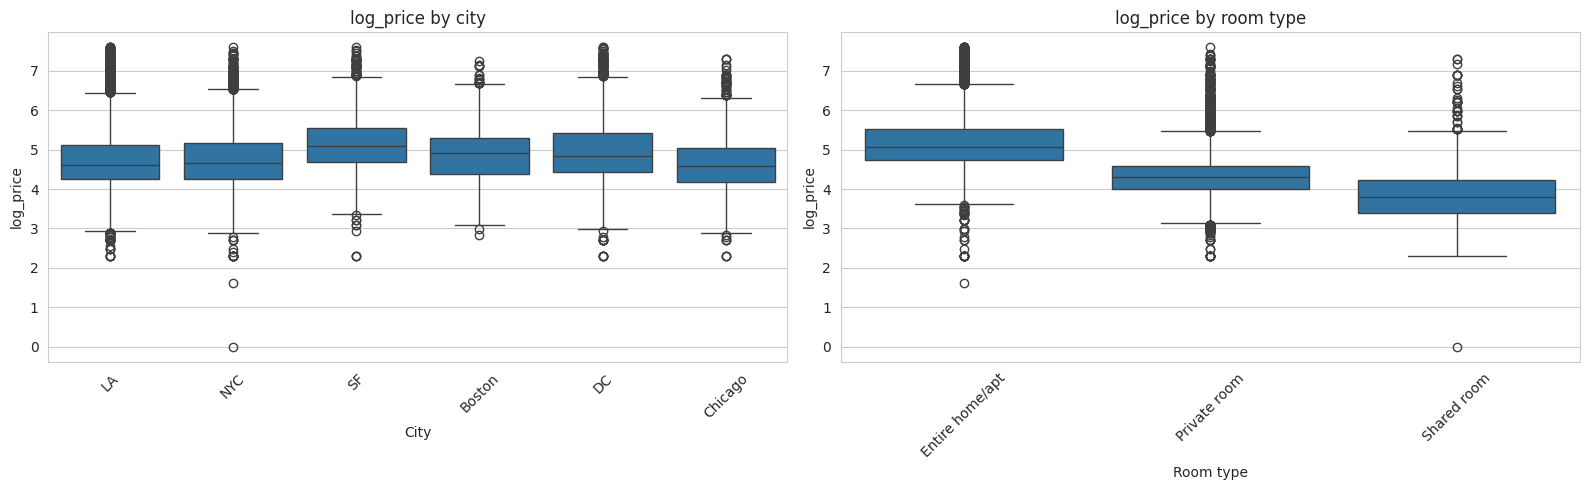

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=data, x='city', y='log_price', ax=axes[0])
axes[0].set_title('log_price by city')
axes[0].set_xlabel('City')
axes[0].set_ylabel('log_price')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=data, x='room_type', y='log_price', ax=axes[1])
axes[1].set_title('log_price by room type')
axes[1].set_xlabel('Room type')
axes[1].set_ylabel('log_price')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Interpretation.** Price clearly depends on both variables. **SF** and **Boston** have the highest median `log_price`, while **Chicago** is the lowest. For room type the ranking is intuitive: **Entire home/apt > Private room > Shared room**. These two categorical features already look like strong predictors, which the correlation matrix below confirms.

## 3. Preprocessing and cleaningIn this section we prepare the data for modeling. We:1. Drop columns that are not useful for a simple model (free text, urls, ids, dates).2. Handle missing values.3. Encode the categorical columns into numbers with `LabelEncoder`.We write this as a single clean function so we can apply **exactly the same steps** to the training set and to the test set (this avoids data leakage and bugs).

In [8]:
# Columns we will NOT use as features:
# - text / url / id columns that are hard to use in a simple model
# - date columns (would need extra work)
drop_columns = ['id', 'amenities', 'description', 'name', 'thumbnail_url',
                'first_review', 'last_review', 'host_since',
                'zipcode', 'neighbourhood', 'host_response_rate']

# Categorical columns we will encode into numbers
categorical_columns = ['property_type', 'room_type', 'bed_type',
                       'cancellation_policy', 'city',
                       'cleaning_fee', 'host_has_profile_pic',
                       'host_identity_verified', 'instant_bookable']

# Numeric feature columns
numeric_features = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
                    'number_of_reviews', 'review_scores_rating',
                    'latitude', 'longitude']

In [9]:
def preprocess(df, encoders=None, fit=True):
    """Clean and encode the dataframe.
    If fit=True we create new LabelEncoders (training set).
    If fit=False we reuse the encoders fitted on the training set (test set).
    Returns the processed feature dataframe and the encoders.
    """
    df = df.copy()

    # 1. Drop unused columns (ignore errors if a column is missing)
    df = df.drop(columns=drop_columns, errors='ignore')

    # 2. Fill missing values
    for col in ['bathrooms', 'bedrooms', 'beds', 'review_scores_rating']:
        df[col] = df[col].fillna(df[col].median())

    # Fill missing categorical values with the string 'missing'
    for col in categorical_columns:
        df[col] = df[col].astype(str).fillna('missing')

    # 3. Encode categorical columns
    if fit:
        encoders = {}
        for col in categorical_columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            encoders[col] = le
    else:
        for col in categorical_columns:
            le = encoders[col]
            # Map unseen categories in the test set to a safe default (0)
            df[col] = df[col].map(
                lambda v: le.transform([v])[0] if v in le.classes_ else 0
            )

    # 4. Keep only the feature columns (drop the target if present)
    feature_cols = numeric_features + categorical_columns
    df = df[feature_cols]

    return df, encoders

### Correlation heatmapAfter encoding, we can look at how each feature correlates with `log_price`. This helps us see which variables are the most useful for prediction.

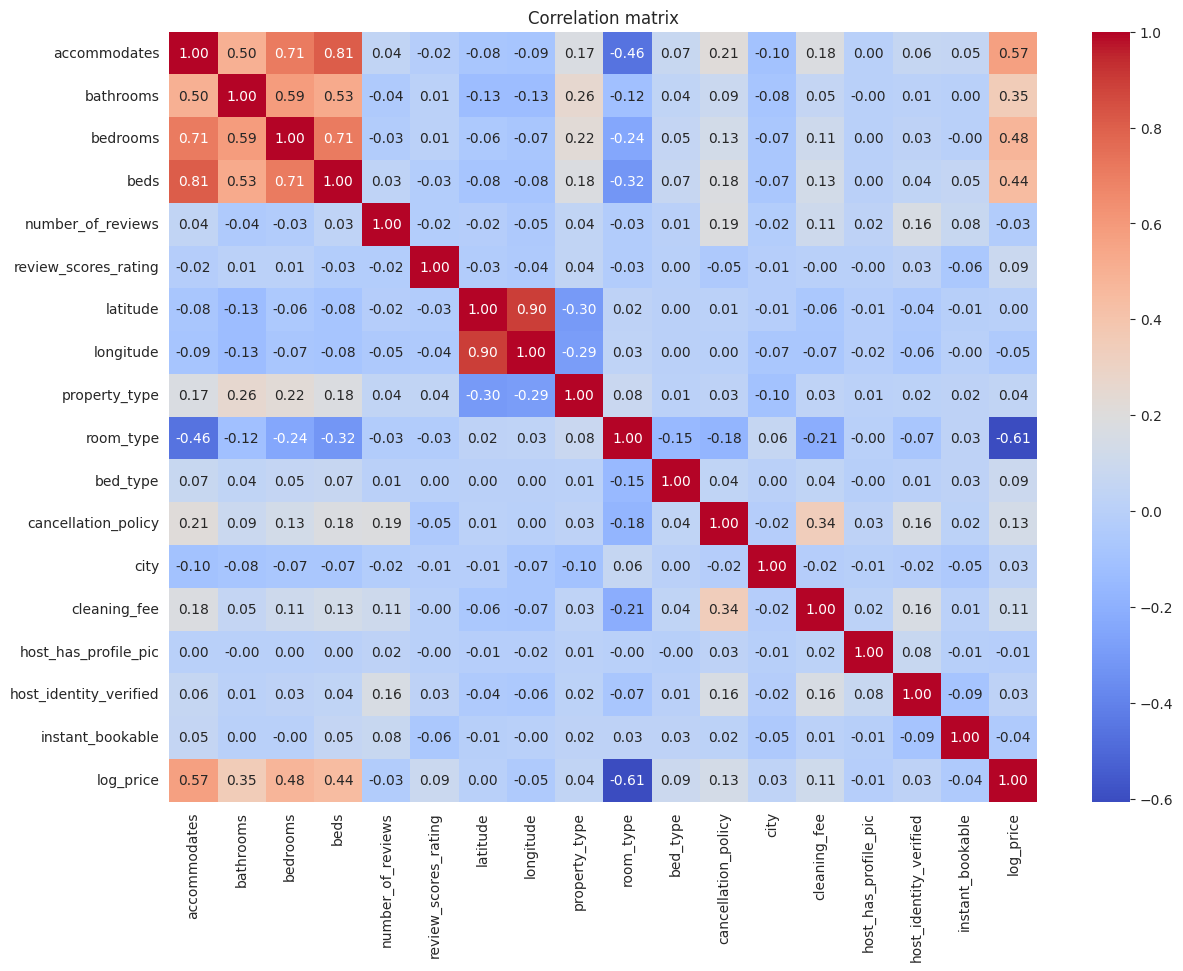

Correlation of each feature with log_price:
log_price                 1.000000
accommodates              0.569175
bedrooms                  0.475260
beds                      0.443553
bathrooms                 0.351840
cancellation_policy       0.134875
cleaning_fee              0.111349
bed_type                  0.091153
review_scores_rating      0.085056
property_type             0.044629
city                      0.030650
host_identity_verified    0.026502
latitude                  0.000427
host_has_profile_pic     -0.014200
number_of_reviews        -0.030763
instant_bookable         -0.044056
longitude                -0.045283
room_type                -0.606202
Name: log_price, dtype: float64


In [10]:
train_raw = pd.read_csv('airbnb_train.csv')
X_encoded, encoders = preprocess(train_raw, fit=True)
corr_df = X_encoded.copy()
corr_df['log_price'] = train_raw['log_price'].values

plt.figure(figsize=(14, 10))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

# Features most correlated with log_price
high_corr = corr_df.corr()['log_price'].sort_values(ascending=False)
print('Correlation of each feature with log_price:')
print(high_corr)

**Interpretation.** The strongest linear signals are `room_type` (**-0.61**, entire-home encoded low / shared-room high) and `accommodates` (**+0.57**), followed by `bedrooms`, `beds` and `bathrooms`. `latitude`, `longitude` and `number_of_reviews` are almost uncorrelated with price on their own, but a tree model can still exploit them through non-linear interactions.

## 4. Prepare the data for modelingWe build the feature matrix `X` and the target `y` from the training file, then split it into a train part and a validation part (80/20 again, inside the training data) so we can measure the quality of each model. Finally we scale the features with `StandardScaler`.

In [11]:
train_raw = pd.read_csv('airbnb_train.csv')

# Features and target
X, encoders = preprocess(train_raw, fit=True)
y = train_raw['log_price']

# Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print('X_train:', X_train_scaled.shape)
print('X_val:  ', X_val_scaled.shape)

X_train: (47430, 17)
X_val:   (11858, 17)


## 5. Train and compare three regression modelsWe train the three models required by the project and compare them using **MAE**, **RMSE** and **R²**:- **Linear Regression** — simple baseline- **Ridge Regression** — linear model with regularization- **Random Forest Regressor** — tree-based model that captures non-linear relationships

In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)

    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f'{name:20s} | MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}')

results_df = pd.DataFrame(results).sort_values('RMSE')
print()
print('Summary (sorted by RMSE, lower is better):')
print(results_df.to_string(index=False))

Linear Regression    | MAE: 0.368 | RMSE: 0.491 | R2: 0.539
Ridge Regression     | MAE: 0.368 | RMSE: 0.491 | R2: 0.539
Random Forest        | MAE: 0.287 | RMSE: 0.397 | R2: 0.699

Summary (sorted by RMSE, lower is better):
            Model      MAE     RMSE       R2
    Random Forest 0.287382 0.397060 0.698746
 Ridge Regression 0.368182 0.491217 0.538930
Linear Regression 0.368182 0.491217 0.538930


**Interpretation.** **Linear** and **Ridge** give essentially identical scores (R² ≈ 0.54): with standardized features the default Ridge penalty barely changes the coefficients, so regularization is not the bottleneck here. **Random Forest** is clearly ahead (R² ≈ 0.70, lower MAE and RMSE) because the price depends on non-linear combinations of features that a linear model cannot capture.

### Visual comparison of the modelsA bar chart makes it easy to compare the RMSE (lower is better) and R² (higher is better) of the three models.

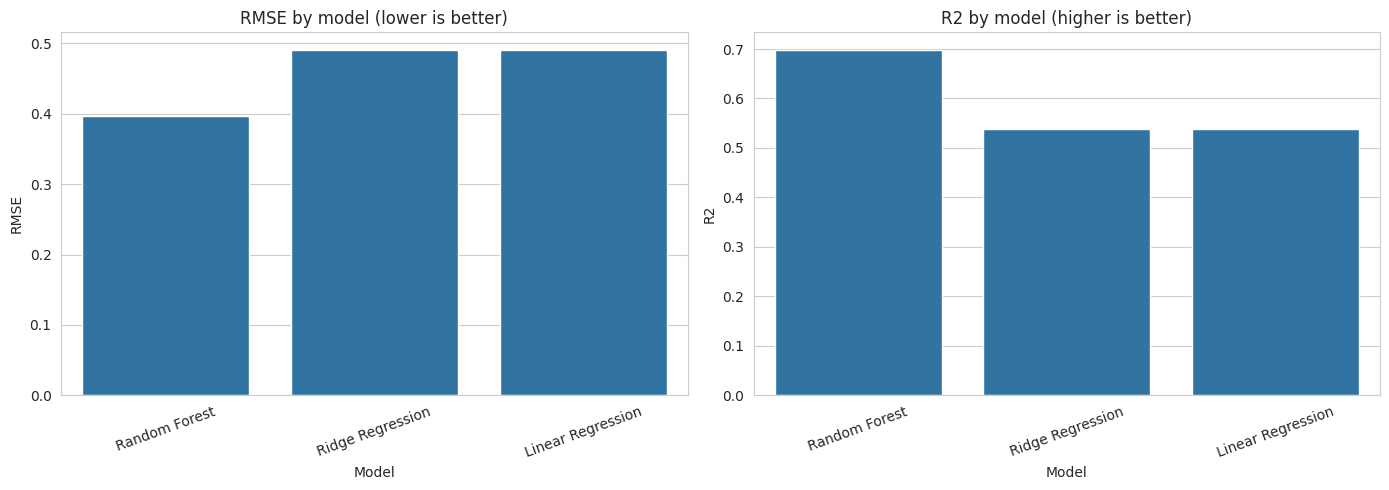

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[0])
axes[0].set_title('RMSE by model (lower is better)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='R2', ax=axes[1])
axes[1].set_title('R2 by model (higher is better)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 6. Best model and predictions vs real valuesBased on the scores above, the **Random Forest** is usually the best model on this dataset because it can capture non-linear relationships between the features and the price. We look at how its predictions compare to the real values on the validation set.

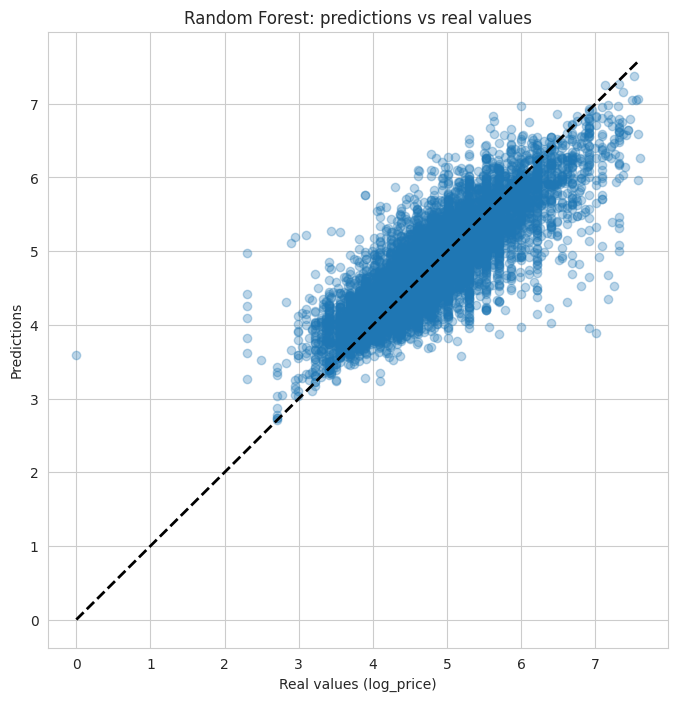

In [14]:
best_model = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200)
best_model.fit(X_train_scaled, y_train)
val_preds = best_model.predict(X_val_scaled)

# Predictions vs real values
plt.figure(figsize=(8, 8))
plt.scatter(y_val, val_preds, alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--', lw=2)
plt.xlabel('Real values (log_price)')
plt.ylabel('Predictions')
plt.title('Random Forest: predictions vs real values')
plt.show()

### Feature importanceThe Random Forest can tell us which features it relies on the most to predict the price.

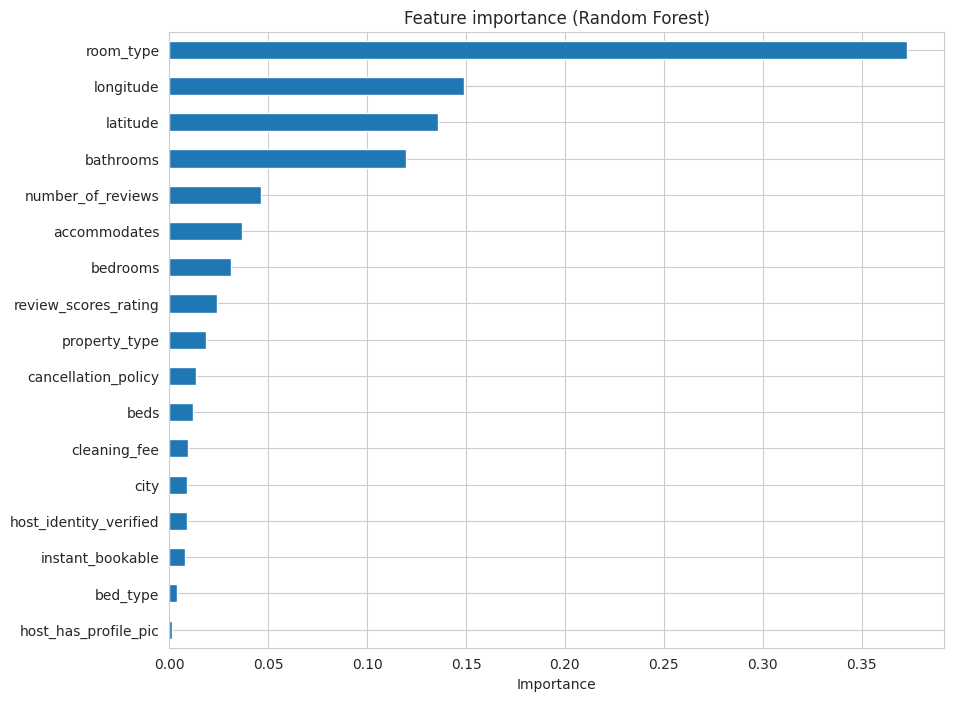

In [15]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh')
plt.title('Feature importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

**Interpretation.** The Random Forest relies mostly on **`room_type`**, **`accommodates`** and the geographic coordinates (**`longitude`**, **`latitude`**), plus `bedrooms`/`bathrooms`. This matches the EDA: capacity and location drive the price. Note that the coordinates matter much more to the tree model than their weak linear correlation suggested.

## 7. Evaluate on the held-out test set (airbnb_test.csv)Finally, we use the 20% test set that we set aside at the very beginning. The model has **never** seen this data, so it gives an honest measure of how well it generalizes to new listings.We reuse the same encoders and scaler that were fitted on the training data (no re-fitting on the test set — this avoids data leakage).

In [16]:
test_raw = pd.read_csv('airbnb_test.csv')

# Apply the SAME preprocessing (fit=False -> reuse training encoders)
X_test, _ = preprocess(test_raw, encoders=encoders, fit=False)
y_test = test_raw['log_price']

# Scale using the scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

# Predict
test_preds = best_model.predict(X_test_scaled)

# Final metrics
mae = mean_absolute_error(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
r2 = r2_score(y_test, test_preds)

print('=== Final results on the held-out test set ===')
print(f'MAE : {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R2  : {r2:.3f}')

=== Final results on the held-out test set ===
MAE : 0.288
RMSE: 0.399
R2  : 0.691


**Interpretation.** The test scores (MAE ≈ 0.29, RMSE ≈ 0.40, R² ≈ 0.69) are almost identical to the validation scores, so the model **generalizes well and is not overfitting**. On the original price scale an MAE of ~0.29 in log units means predictions are typically within roughly ±30% of the true nightly price — a useful estimate, but not precise enough to set prices automatically.

In [17]:
# Save the predictions to a CSV file
output = pd.DataFrame({
    'real_log_price': y_test.values,
    'predicted_log_price': test_preds
})
output.to_csv('airbnb_predictions.csv', index=False)
print('Predictions saved to airbnb_predictions.csv')
print(output.head())

Predictions saved to airbnb_predictions.csv
   real_log_price  predicted_log_price
0        3.806662             3.865585
1        4.941642             4.653907
2        4.941642             4.819651
3        4.867534             5.443705
4        3.663562             3.968774


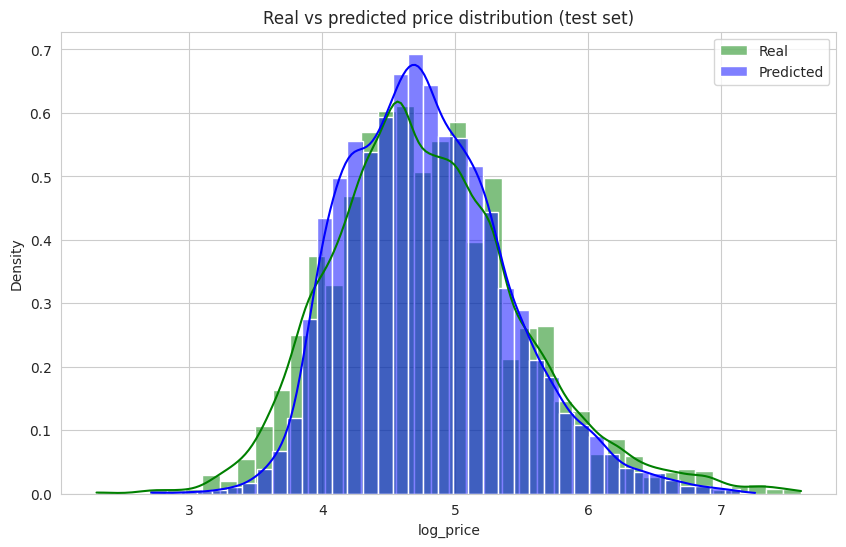

In [18]:
# Distribution of the predictions vs the real values
plt.figure(figsize=(10, 6))
sns.histplot(y_test, kde=True, color='green', bins=40, label='Real', stat='density')
sns.histplot(test_preds, kde=True, color='blue', bins=40, label='Predicted', stat='density')
plt.xlabel('log_price')
plt.title('Real vs predicted price distribution (test set)')
plt.legend()
plt.show()

## 8. Responsible AIA few important points about using this model responsibly:- **Data bias:** the dataset only covers 6 US cities and comes from 2017-2018. Prices have changed a lot since then, so the model should **not** be used to set real prices today.- **Geographic bias:** neighborhood and city strongly influence the price. A model like this could reinforce existing price differences between areas.- **Ethical use:** automated pricing tools can hurt both hosts (if the estimate is too low) and guests (if it pushes prices up). Predictions should be treated as a rough guide, not a decision.- **Honest reporting:** we report MAE, RMSE and R² on a test set the model never saw, instead of only showing the best training score. We do not claim the model is perfect.- **No personal data:** we removed free-text and host-related columns, so the model does not rely on personal information.- **AI tools:** we used AI assistants only for help with debugging, code explanation and grammar. We understand and can explain every step of this notebook.

## 9. ConclusionIn this project we built a full data science pipeline to predict Airbnb listing prices:1. We split the Kaggle dataset ourselves into 80% training and 20% test.2. We explored and visualized the data (distributions, price by city and room type, correlations).3. We cleaned the data, handled missing values and encoded the categorical features.4. We trained and compared three regression models (Linear, Ridge, Random Forest).5. We evaluated the best model honestly on a held-out test set using MAE, RMSE and R².**Main finding:** the Random Forest gives the best results because it captures the non-linear relationships between the property features and the price. The most important features are usually `room_type`, `accommodates`, `bedrooms`, `bathrooms` and the city location.**Future work:** use the text columns (`amenities`, `description`) with NLP, add the neighborhood back with better encoding, and tune the Random Forest hyperparameters to improve accuracy.